In [1]:
import numpy as np
import matplotlib.pyplot as plt

Oscilador armònico.

Sabemos que la ecuaciòn diferencial del oscilador armònico es
$$
\ddot x + \omega_0²x=0
$$
hacemos $\tau=\omega_0t$ y entonces $\frac{d}{dt}$

In [21]:
####MÈTODO DE EULER ###

def Euler(g,x0,t): #t es un arreglo 
    h = t[1]- t[0]
    sol = np.zeros( (len(x0),len(t)) ) #Es una matriz de x0 columnas
    sol[:,0] = x0  #acomoda la posiciòn inicial

    for i in range(len(t)-1):
        sol[:,i+1] = sol[:,i] + h*g(sol[:,i],t[i])

    return sol

In [22]:
#Estas dos funciones hacen lo mismo
def osc_old(x_vx,t):
    x = x_vx[0]
    vx = x_vx[1]
    dx = vx
    dvx = -x

    return np.array([dx,dvx])

def osc(x_vx,t):
    return np.array([x_vx[1],-x_vx[0]])

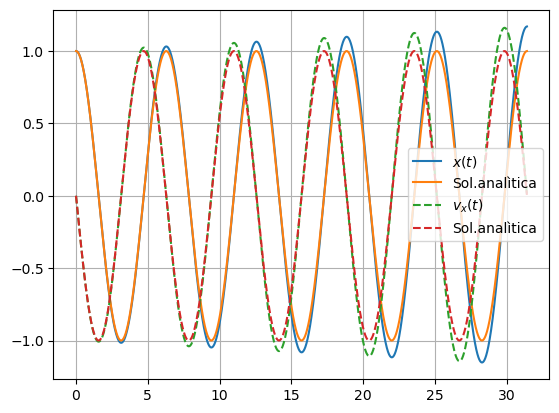

In [24]:
x_ini = np.array([1,0])
t = np.arange(0,10*np.pi,0.01)

sol = Euler(osc,x_ini,t)

plt.plot(t,sol[0,:], label=r'$x(t)$')
plt.plot(t,np.cos(t), label=r'Sol.analìtica')
plt.plot(t,sol[1,:],'--', label=r'$v_x(t)$')
plt.plot(t,-np.sin(t),'--', label=r'Sol.analìtica')

plt.legend(),plt.grid()
plt.show()
##Pasitos màs chiquitos refinan, pero iguakll sigo divergiendo conforme el tiempo

In [31]:
###Mètodo otro
def RK2(g,x0,t): #t es un arreglo 
    h = t[1]- t[0]
    sol = np.zeros( (len(x0),len(t)) ) #Es una matriz de x0 columnas
    sol[:,0] = x0  #acomoda la posiciòn inicial

    for i in range(len(t)-1):
        t_med = t[i] + 0.5*h
        sol_med = sol[:,i] + 0.5*h*g(sol[:,i],t[i])
        sol[:,i+1] = sol[:,i] + h*g(sol_med,t_med)

    return sol

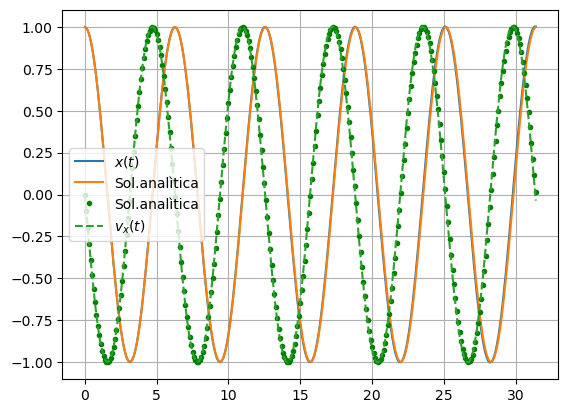

In [36]:
x_ini = np.array([1,0])
t = np.arange(0,10*np.pi,0.1)

sol = RK2(osc,x_ini,t)

plt.plot(t,sol[0,:], label=r'$x(t)$')
plt.plot(t,np.cos(t), label=r'Sol.analìtica')
plt.plot(t,-np.sin(t),'.', label=r'Sol.analìtica', color ='green')
plt.plot(t,sol[1,:],'--', label=r'$v_x(t)$')

plt.legend(),plt.grid()
plt.show()
##Veamos que estàn pràcticamente sobrepuestas

In [39]:
a, b = np.array([[1,2],[3,4]]) , np.array([3,6])

a , b , a*b, np.dot(a,b)

(array([[1, 2],
        [3, 4]]),
 array([3, 6]),
 array([[ 3, 12],
        [ 9, 24]]),
 array([15, 33]))

In [52]:
def Euler_mejorado(g,x0,t,Jac):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0),len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        sol[:,i+1] = sol[:,i] + h*g(sol[:,i],t[i])
      x_ini = np.array([1,0])
t = np.arange(0,10*np.pi,0.1)
sol = Euler_mejorado(osc,x_ini,t,J_osc)
plt.plot(t,sol[0,:],label=r'$x(t)$')
plt.plot(t,np.cos(t),':',label=r'Sol. analítica') # Solucion analitica de x
plt.plot(t,sol[1,:],'--',label=r'$v_x(t)$')
plt.plot(t,-np.sin(t),'-.',label=r'Sol. analítica') # Solucion analitica de v_x
plt.grid(),plt.legend()
plt.show()

  sol[:,i+1] += 0.5*np.dot(Jac(sol[:,i],t[i]),g(sol[:,i],t[i]))*h**2
    return sol


In [53]:
def J_osc(x_vx,t):
    return np.array([[0,1],[-1,0]])


In [54]:
x_ini = np.array([1,0])
t = np.arange(0,10*np.pi,0.1)
sol = Euler_mejorado(osc,x_ini,t,J_osc)
plt.plot(t,sol[0,:],label=r'$x(t)$')
plt.plot(t,np.cos(t),':',label=r'Sol. analítica') # Solucion analitica de x
plt.plot(t,sol[1,:],'--',label=r'$v_x(t)$')
plt.plot(t,-np.sin(t),'-.',label=r'Sol. analítica') # Solucion analitica de v_x
plt.grid(),plt.legend()
plt.show()


##Veamos que estàn pràcticamente sobrepuestas

ValueError: could not broadcast input array from shape (2,2) into shape (2,)

In [55]:
###RK4
def RK4(g,x0,t): #t es un arreglo 
    h = t[1]- t[0]
    sol = np.zeros( (len(x0),len(t)) ) #Es una matriz de x0 columnas
    sol[:,0] = x0  #acomoda la posiciòn inicial

    for i in range(len(t)-1):
        k1 = g(sol[:,i],t[i])
        k2 = g(sol[:,i]+0.5*k1*h, t[i]+0.5*h)
        k3 = g(sol[:,i]+0.5*k2*h, t[i]+0.5*h)
        k4 = g(sol[:,i]k3*h, t[i]+h)
        sol[:,i+1] = sol[:,i] + (1/6)*h*(k1 + 2*k2 + 2*k3 + k4)

    return sol

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2572937647.py, line 11)

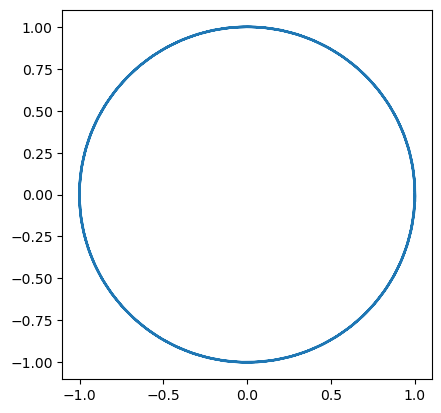

In [57]:
plt.plot(sol[0,:],sol[1,:])
plt.gca().set_aspect('equal')
plt.show()